# Shower observables

Six geometric and calorimetric quantities that are **not** classifier inputs:
shower energy, corrected energy `E_c`, impact parameter `b`, travel distance
`d`, shower start `z`, and the angle to the beam axis.

The question: photon identification cannot separate signal photons from
`γ:other`, because the two are physically identical at the PFO level. Only
*provenance* can — does the shower point back to the beam interaction vertex?
These variables encode provenance. This notebook asks whether they carry enough
information to be worth adding as features.

## Setup

In [14]:
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.metrics import roc_auc_score

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS, SPECIES_ALL,
                                 species_label, target_config)
from utils.hist_utils import hist_ratio_grid, stacked_by_species

TARGET    = "photon"       # "pion" | "photon"
MODEL_SET = "all8"         # "base4" | "all8"
cfg = target_config(TARGET)

# The score-scatter in the last cell asks a different question depending on
# which model is loaded:
#   base4 -- the classifier does not see b, d or beam_angle, so no structure
#            means the information is genuinely absent from its inputs
#   all8  -- the classifier does see them, so structure means it used them
SCORE_TITLE = {
    'base4': 'Is this information absent from what the classifier sees?',
    'all8':  'Did the classifier use the provenance features?',
}[MODEL_SET]

PREPARED_DIR = PROJECT_ROOT / "prepared" / "prepared-mc"
PRED_MC_DIR  = PROJECT_ROOT / "predictions" / "predictions-mc"
PLOTS_DIR    = PROJECT_ROOT / "plots" / "shower-observables" / TARGET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = PRED_MC_DIR / f"hybrid_cnn_mlp_{MODEL_SET}{cfg['suffix']}.pkl"

with open(PREPARED_DIR / "test_tracks.pkl", "rb") as f:
    tracks = pickle.load(f)

species   = np.array([species_label(t) for t in tracks])
is_signal = np.array([cfg['is_signal'](t) for t in tracks])

SHOW   = SPECIES_ALL
counts = {sp: int((species == sp).sum()) for sp in SHOW}

print(f"Loaded {len(tracks):,} PFOs")
print(f"Signal ({cfg['signal_name']}): {is_signal.sum():,} "
      f"({100*is_signal.mean():.1f}%)")
print(f"Main background ({cfg['main_bkg']}): "
      f"{int((species == cfg['main_bkg']).sum()):,}")
print(f"\nclassifier for the score plot: {MODEL_SET}")
print(f"  -> {SCORE_TITLE}")

Loaded 126,817 PFOs
Signal ($\gamma$ (beam $\pi^0$)): 19,753 (15.6%)
Main background ($\gamma$:other): 10,190

classifier for the score plot: all8
  -> Did the classifier use the provenance features?


## Building the observables

`b` and `d` come straight from the ntuple. The angle to the beam axis is
computed here: the angle between the shower's own direction and the vector from
the beam end point to the shower start. A small angle means the shower points
away from the interaction vertex, which is what a real π⁰ decay photon should
do.

In [15]:
def xyz(rec):
    return np.array([float(rec['x']), float(rec['y']), float(rec['z'])])


def theta_to_beam_axis(t):
    """Angle (deg) between the shower direction and the
    beam-end -> shower-start vector."""
    v = xyz(t['shower_start_pos']) - xyz(t['beam_end_pos'])
    s = xyz(t['shower_direction'])
    nv, ns = np.linalg.norm(v), np.linalg.norm(s)
    if nv == 0 or ns == 0:
        return np.nan
    c = np.clip(np.dot(v, s) / (nv * ns), -1.0, 1.0)
    return float(np.degrees(np.arccos(c)))


data = {
    'shower energy [MeV]':        np.array([float(t['shower_energy']) for t in tracks]),
    'corrected energy E_c [MeV]': np.array([float(t.get('E_c', np.nan)) for t in tracks]),
    'impact parameter b [cm]':    np.array([float(t['b']) for t in tracks]),
    'travel distance d [cm]':     np.array([float(t['d']) for t in tracks]),
    'shower start z [cm]':        np.array([xyz(t['shower_start_pos'])[2] for t in tracks]),
    'angle to beam axis [deg]':   np.array([theta_to_beam_axis(t) for t in tracks]),
}

# Extra variables used only for the correlation check, not plotted on their own.
extra = {
    'track length [cm]': np.array([float(t['track_length']) for t in tracks]),
    'track score':       np.array([float(t['track_score']) for t in tracks]),
}

RANGES = {
    'shower energy [MeV]':        (0, 400),
    'corrected energy E_c [MeV]': (100, 500),
    'impact parameter b [cm]':    (0, 25),
    'travel distance d [cm]':     (0, 60),
    'shower start z [cm]':        (0, 300),
    'angle to beam axis [deg]':   (0, 180),
}

NBINS = 50

for name, v in data.items():
    n_nan = int(np.isnan(v).sum())
    print(f"{name:<28} NaN: {n_nan:>7,} ({100*n_nan/len(v):5.1f}%)   "
          f"median (finite): {np.nanmedian(v):.1f}")

shower energy [MeV]          NaN:       0 (  0.0%)   median (finite): 128.4
corrected energy E_c [MeV]   NaN:  26,850 ( 21.2%)   median (finite): 244.3
impact parameter b [cm]      NaN:       0 (  0.0%)   median (finite): 3.1
travel distance d [cm]       NaN:       0 (  0.0%)   median (finite): 5.8
shower start z [cm]          NaN:       0 (  0.0%)   median (finite): 98.8
angle to beam axis [deg]     NaN:       0 (  0.0%)   median (finite): 47.8


## Composition by species

Stacked raw counts, following the plotting convention agreed on 5 August: no
area normalisation, stacked for species composition. The log-scale version
below reveals the low-statistics tails.

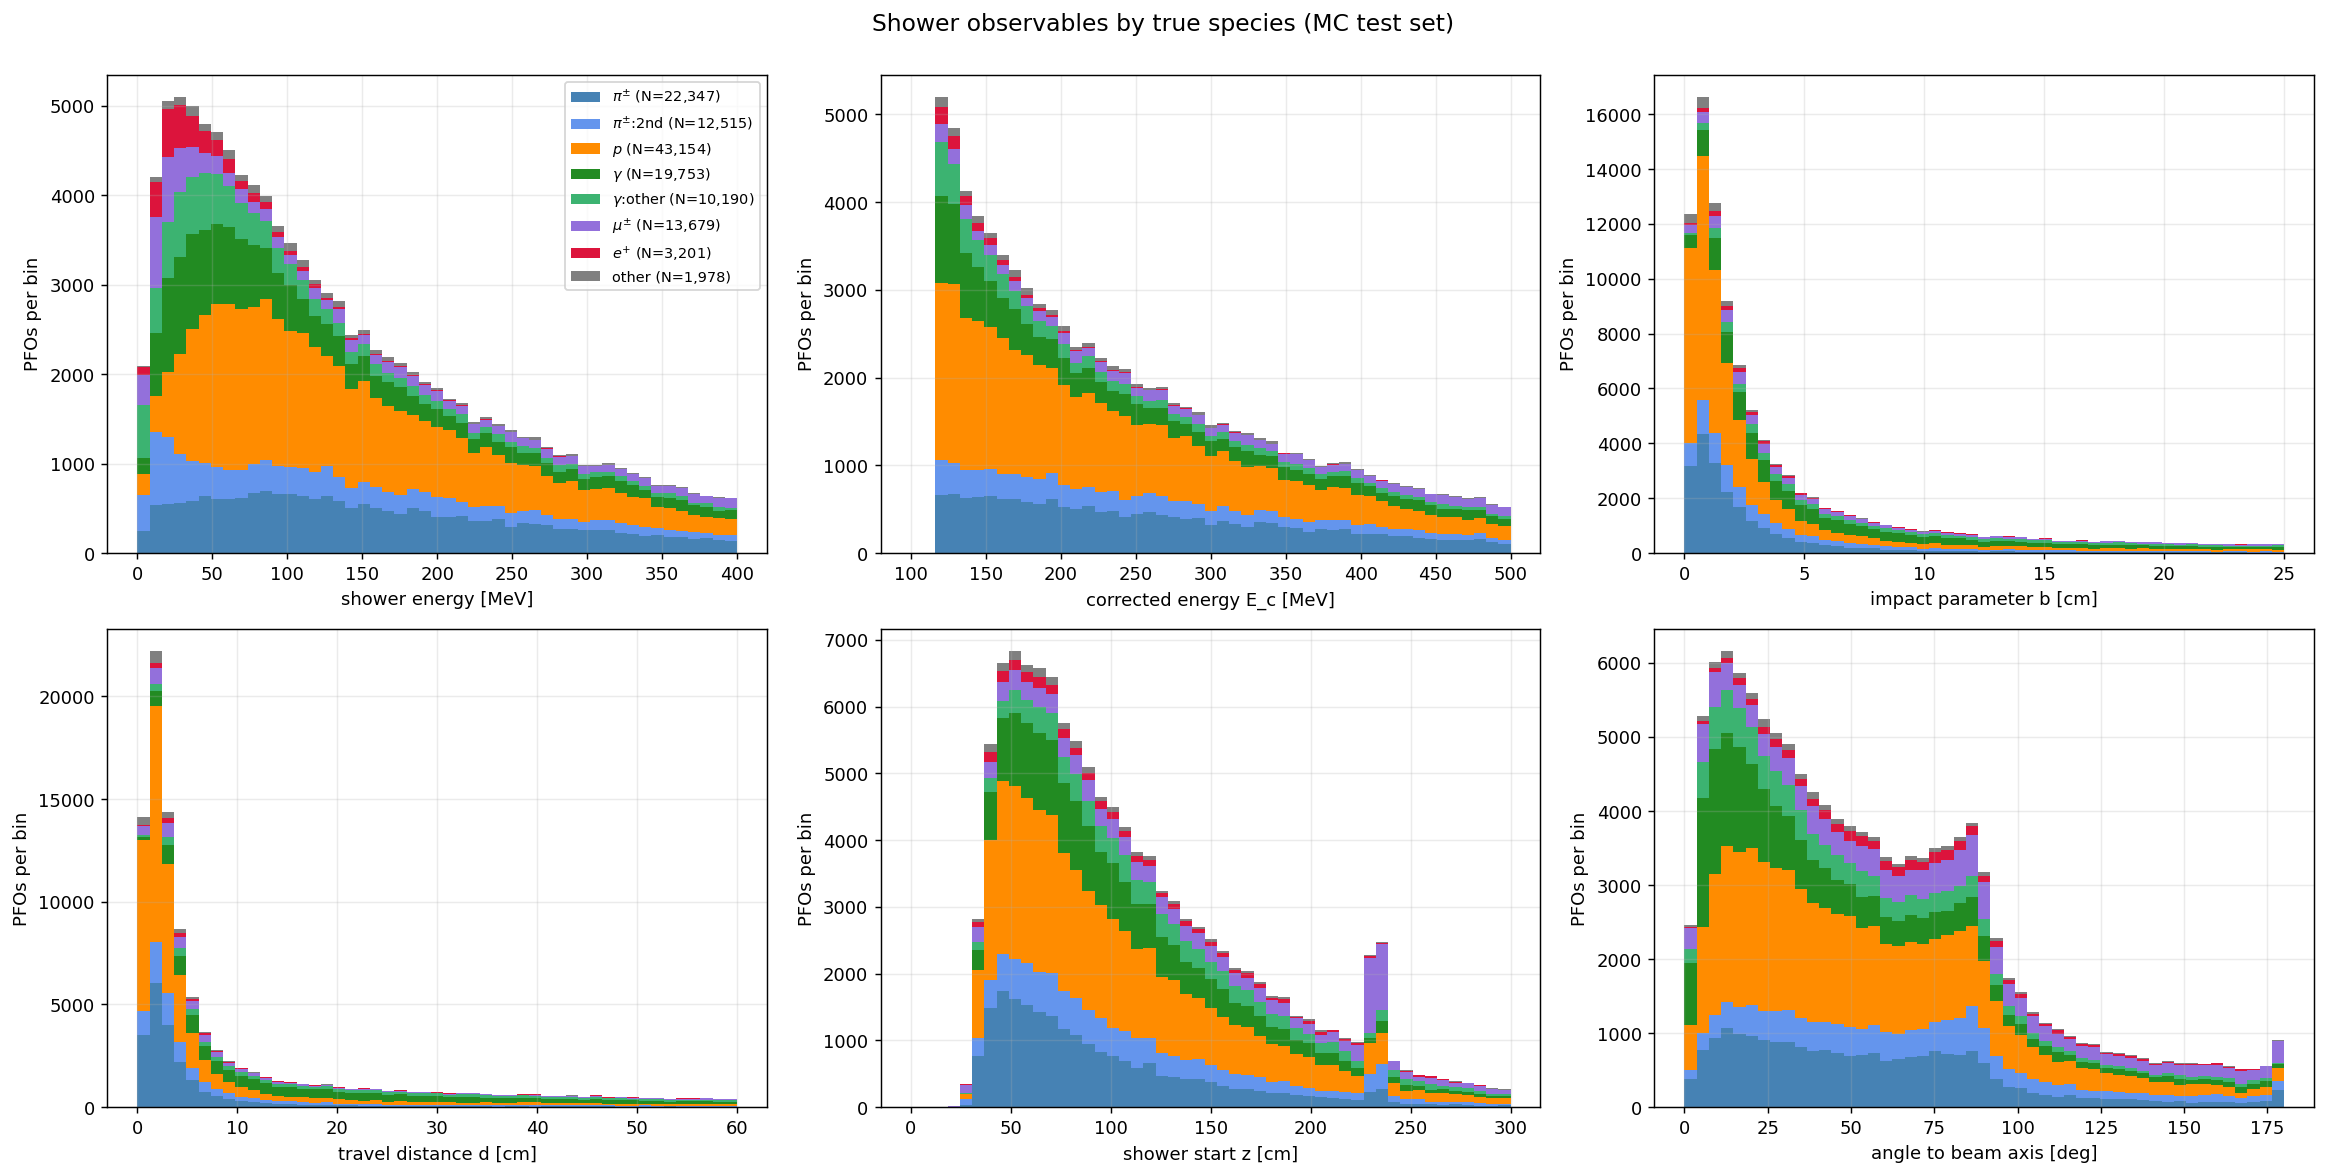

Saved /home/pemb7173/PDSP-pion-classification/plots/shower-observables/photon/shower_observables_by_species_photon.pdf


In [16]:
# stacked by species
stacked_by_species(
    data, species, SHOW, SPECIES_COLORS, RANGES, nbins=NBINS,
    suptitle='Shower observables by true species (MC test set)',
    out_path=PLOTS_DIR / f"shower_observables_by_species_{TARGET}.pdf",
)

## Signal versus background

Raw counts above, **signal fraction** below. The lower panel is
S / (S + B) per bin — the per-bin purity — with the dashed line at the overall
signal fraction. Bins above the line are signal-enriched.

A plain S/B ratio would be uninformative here: signal is only ~16% of the
sample, so every bin would sit near 0.16 regardless of shape.

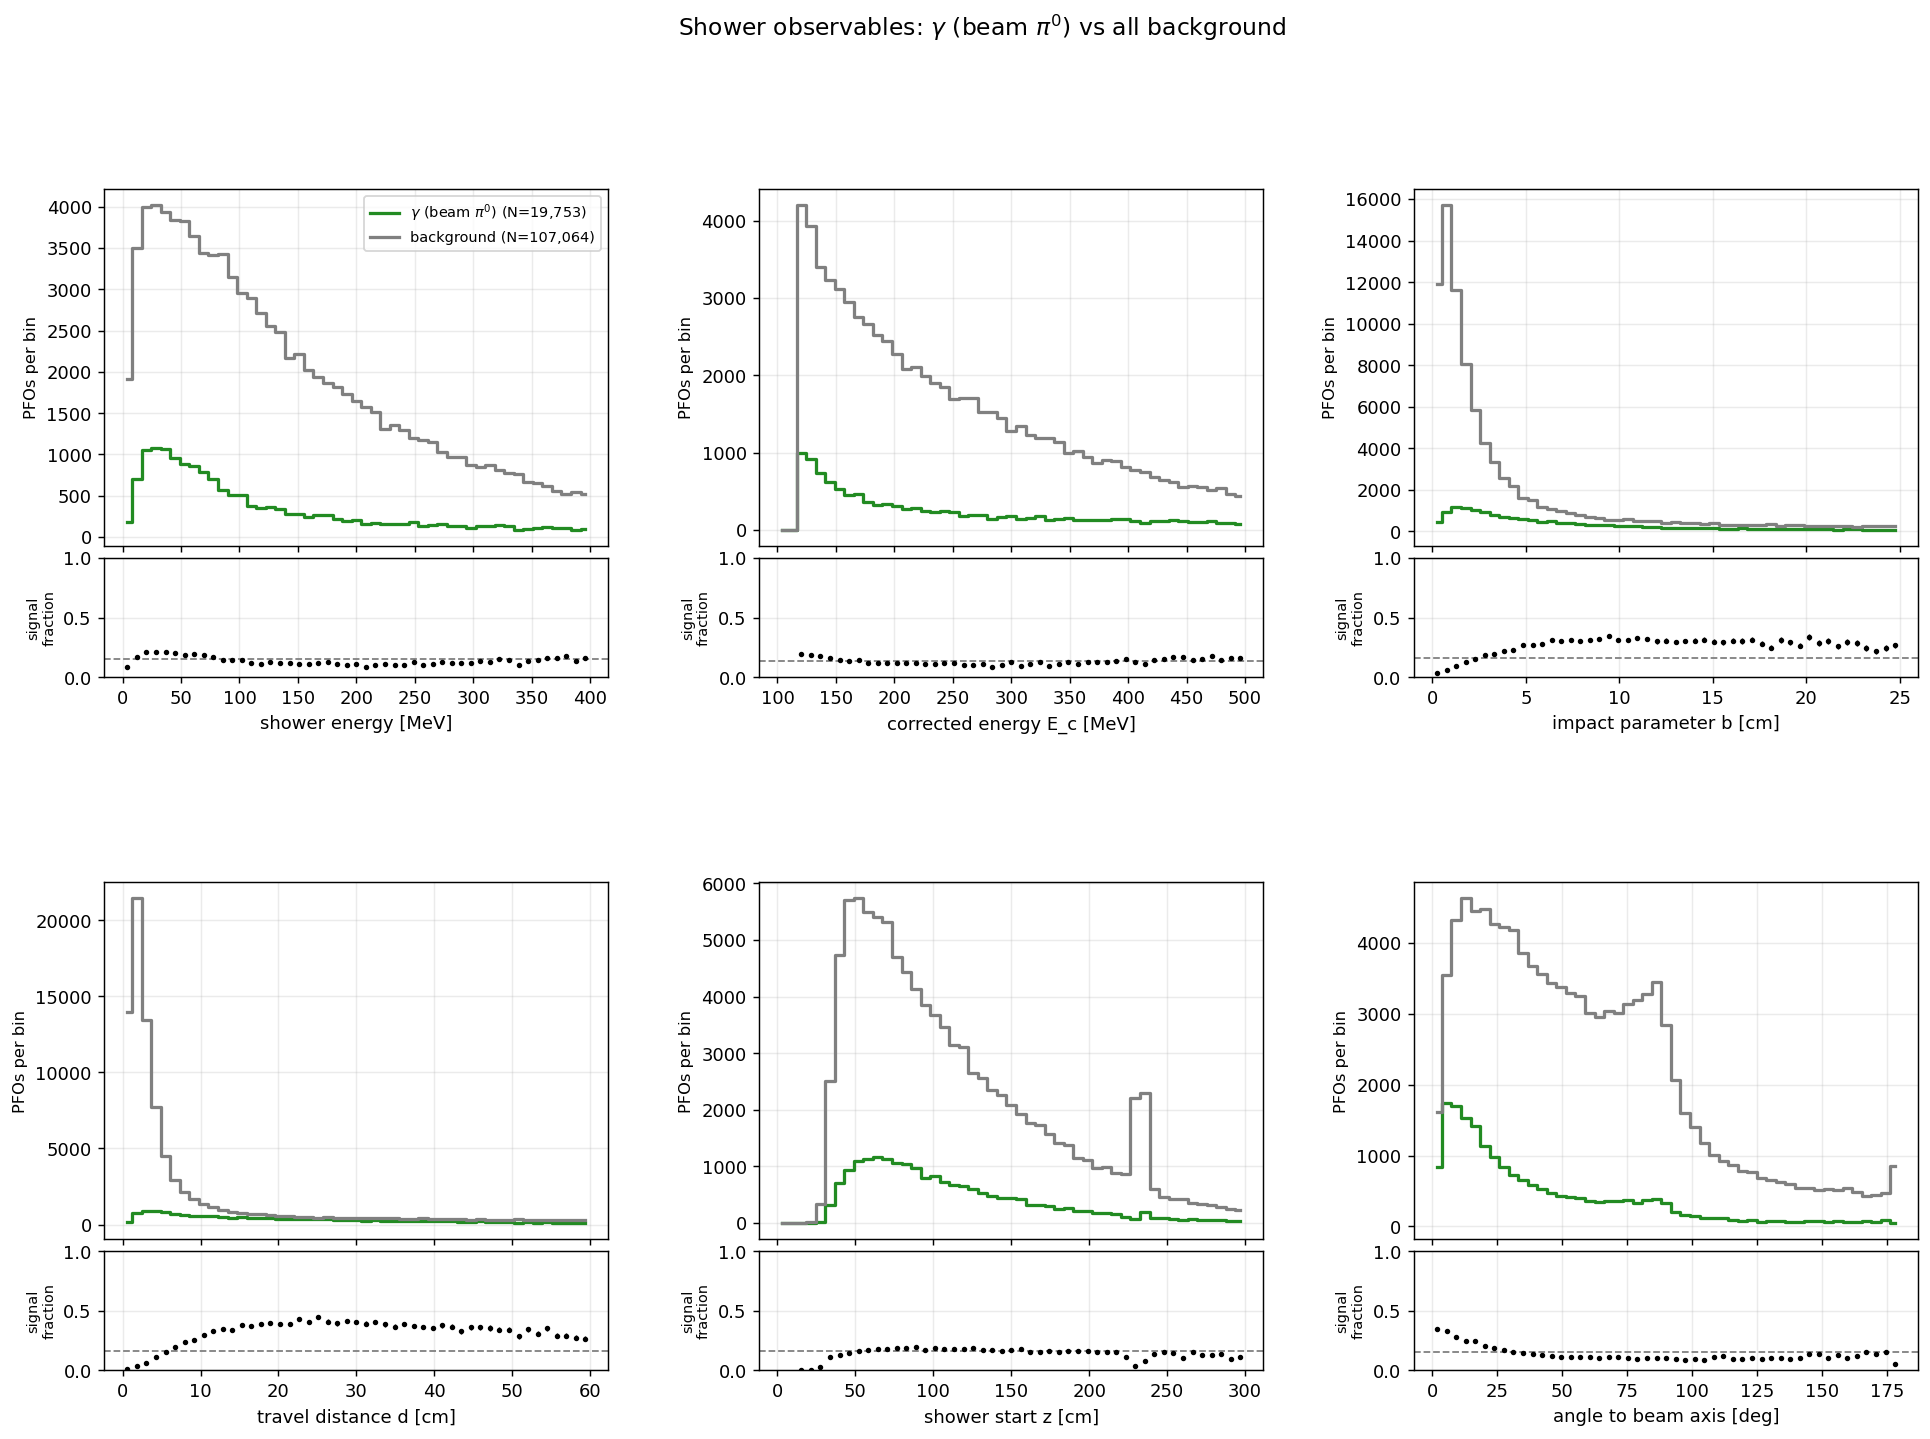

Saved /home/pemb7173/PDSP-pion-classification/plots/shower-observables/photon/shower_signal_vs_background_photon.pdf


In [17]:
groups = [
    (cfg['signal_name'], is_signal,  cfg['signal_colour']),
    ('background',       ~is_signal, 'grey'),
]

hist_ratio_grid(
    data, groups, RANGES, nbins=NBINS,
    ratio_pair=(cfg['signal_name'], 'background'),
    ratio_mode='fraction',
    suptitle=f"Shower observables: {cfg['signal_name']} vs all background",
    out_path=PLOTS_DIR / f"shower_signal_vs_background_{TARGET}.pdf",
)

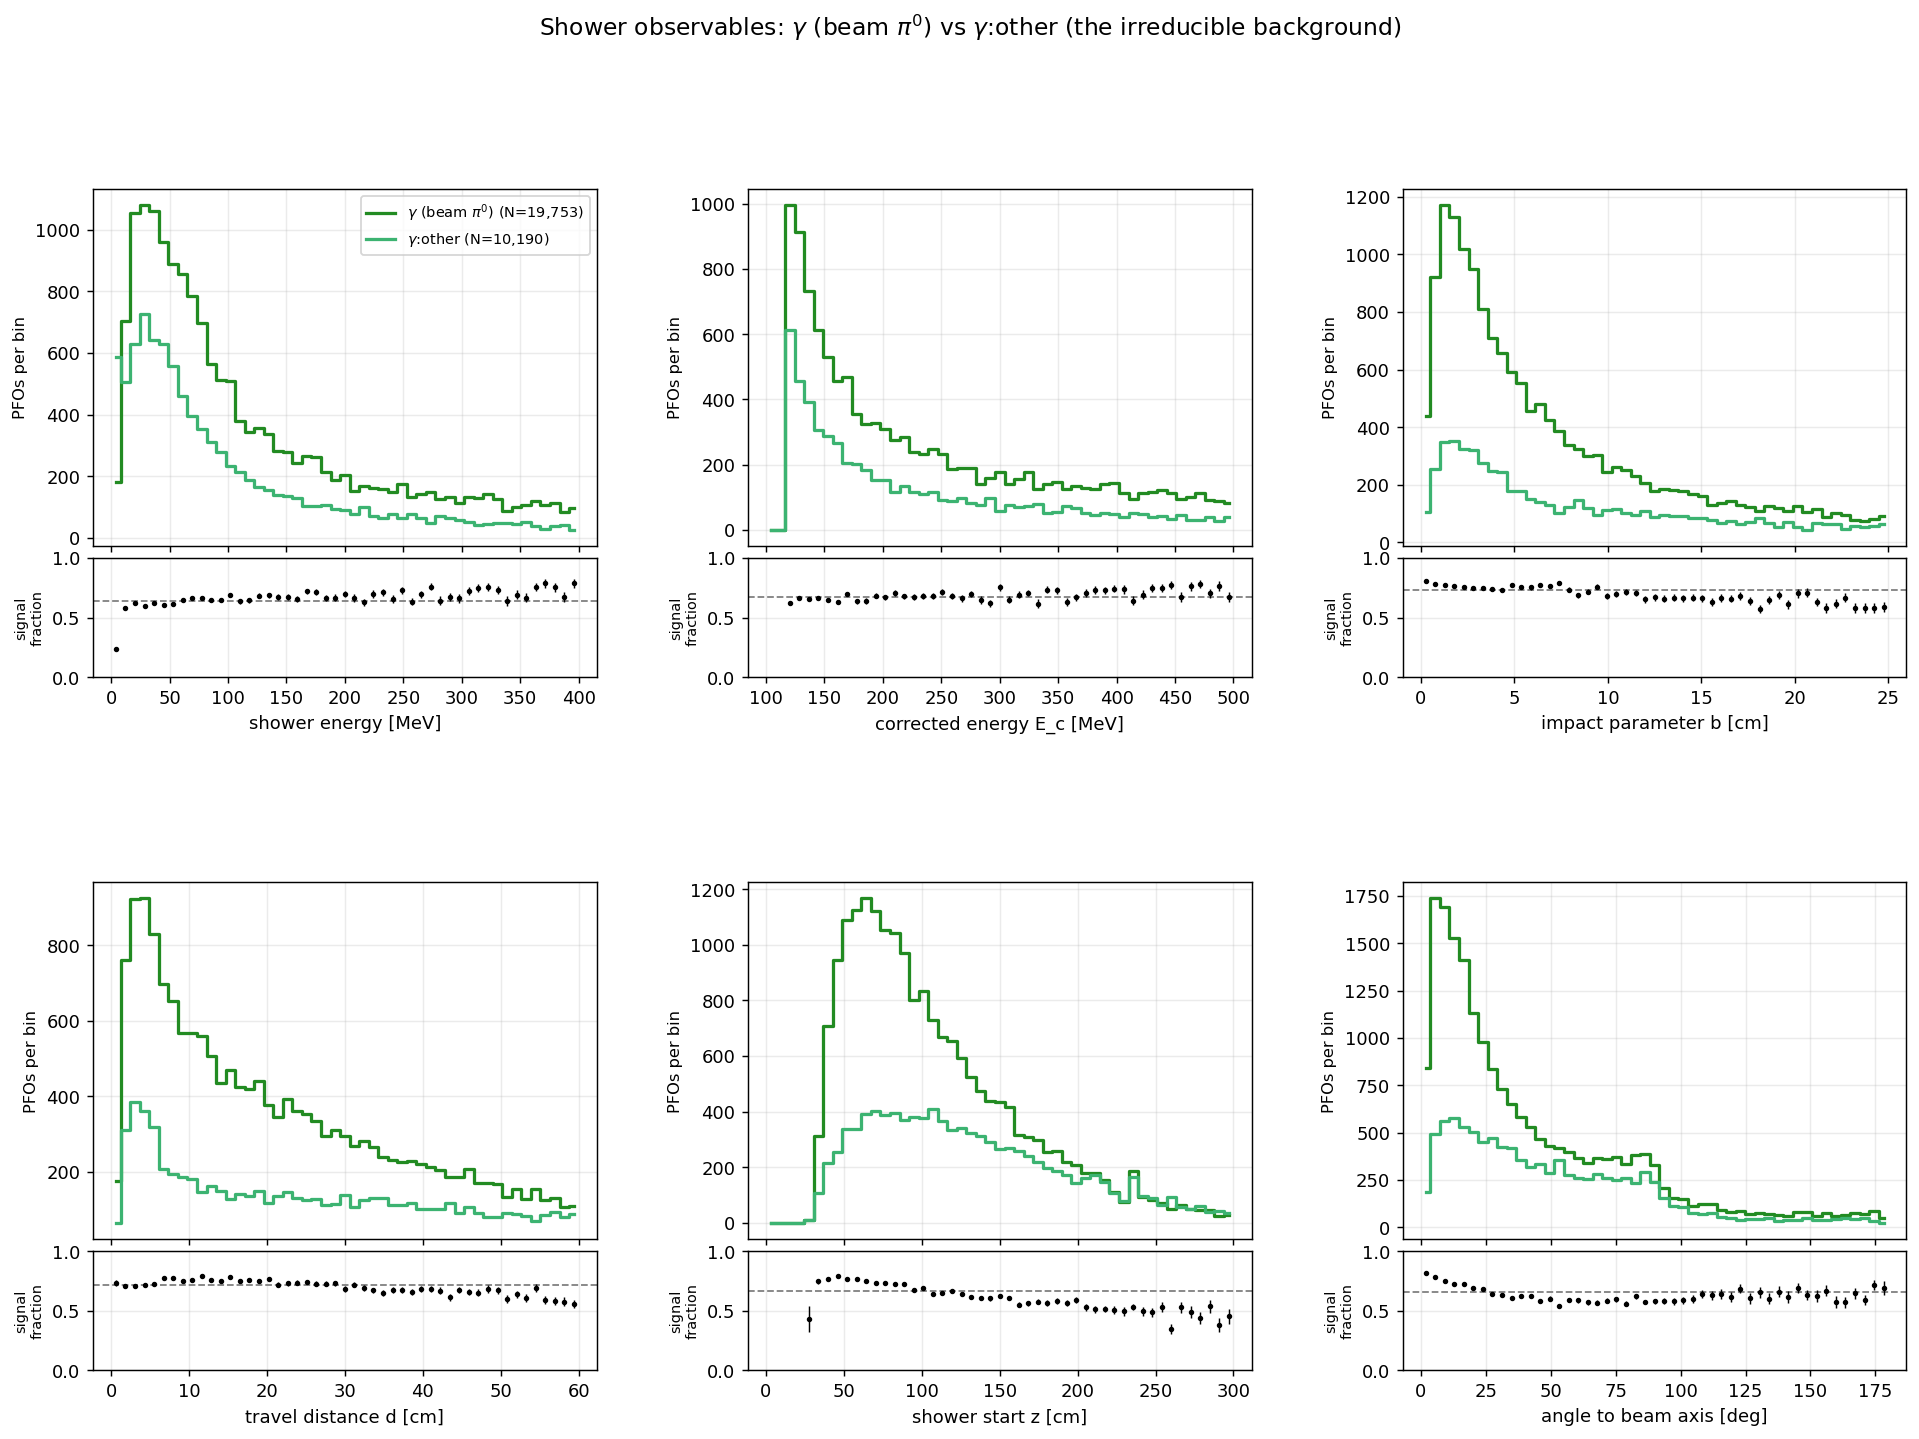

Saved /home/pemb7173/PDSP-pion-classification/plots/shower-observables/photon/shower_signal_vs_mainbkg_photon.pdf


In [18]:
# signal vs background only

# all background is dominated by protons and pions, which the classifier
# already rejects. The comparison that matters for purity is signal against
# the irreducible background (real photons that are not from the beam pi0)
main_bkg_mask = (species == cfg['main_bkg'])
sub = is_signal | main_bkg_mask

groups_irr = [
    (cfg['signal_name'], is_signal,     cfg['signal_colour']),
    (cfg['main_bkg'],    main_bkg_mask, 'mediumseagreen'),
]

hist_ratio_grid(
    {n: np.where(sub, v, np.nan) for n, v in data.items()},
    groups_irr, RANGES, nbins=NBINS,
    ratio_pair=(cfg['signal_name'], cfg['main_bkg']),
    ratio_mode='fraction',
    suptitle=f"Shower observables: {cfg['signal_name']} vs {cfg['main_bkg']} "
             f"(the irreducible background)",
    out_path=PLOTS_DIR / f"shower_signal_vs_mainbkg_{TARGET}.pdf",
)

## Single-variable separation power

AUC of each variable taken alone. 0.5 means useless; further from 0.5 in either
direction means more discriminating (below 0.5 simply means anti-correlated
with signal, which is equally usable).

Two rankings are computed. The first is against **all** background, which is
inflated by the easy track backgrounds the classifier already rejects. The
second restricts to signal versus the main background — the number that
actually matters.

In [19]:
# AUC all background
def auc_table(variables, mask, title):
    print(title)
    print(f"{'variable':<30}{'AUC':>8}{'|AUC-0.5|':>12}{'usable':>9}")
    print("-" * 59)
    rows = []
    for n, v in variables.items():
        ok = np.isfinite(v) & mask
        if ok.sum() < 100 or is_signal[ok].sum() < 10:
            continue
        a = roc_auc_score(is_signal[ok], v[ok])
        rows.append((n, a, abs(a - 0.5), ok.sum() / max(mask.sum(), 1)))
    for n, a, sep, frac in sorted(rows, key=lambda r: -r[2]):
        print(f"{n:<30}{a:>8.3f}{sep:>12.3f}{100*frac:>8.0f}%")
    print()
    return rows


all_vars = {**data, **extra}
rows_all = auc_table(all_vars, np.ones(len(tracks), bool),
                     "vs ALL background")

vs ALL background
variable                           AUC   |AUC-0.5|   usable
-----------------------------------------------------------
track score                      0.133       0.367     100%
travel distance d [cm]           0.677       0.177     100%
angle to beam axis [deg]         0.364       0.136     100%
impact parameter b [cm]          0.619       0.119     100%
track length [cm]                0.465       0.035     100%
shower start z [cm]              0.474       0.026     100%
shower energy [MeV]              0.480       0.020     100%
corrected energy E_c [MeV]       0.512       0.012      79%



In [20]:
# AUC main background only
rows_irr = auc_table(all_vars, sub,
                     f"vs {cfg['main_bkg']} ONLY  ({int(sub.sum()):,} PFOs)")

# Side-by-side ranking: which variables survive the restriction?
d_all = {n: a for n, a, _, _ in rows_all}
d_irr = {n: a for n, a, _, _ in rows_irr}

print(f"{'variable':<30}{'AUC all':>10}{'AUC irr':>10}{'change':>10}")
print("-" * 60)
for n in sorted(d_irr, key=lambda k: -abs(d_irr[k] - 0.5)):
    if n in d_all:
        print(f"{n:<30}{d_all[n]:>10.3f}{d_irr[n]:>10.3f}"
              f"{abs(d_irr[n]-0.5) - abs(d_all[n]-0.5):>+10.3f}")

vs $\gamma$:other ONLY  (29,943 PFOs)
variable                           AUC   |AUC-0.5|   usable
-----------------------------------------------------------


impact parameter b [cm]          0.346       0.154     100%
travel distance d [cm]           0.372       0.128     100%
shower start z [cm]              0.384       0.116     100%
shower energy [MeV]              0.594       0.094     100%
angle to beam axis [deg]         0.415       0.085     100%
track length [cm]                0.575       0.075     100%
corrected energy E_c [MeV]       0.569       0.069      70%
track score                      0.511       0.011     100%

variable                         AUC all   AUC irr    change
------------------------------------------------------------
impact parameter b [cm]            0.619     0.346    +0.035
travel distance d [cm]             0.677     0.372    -0.049
shower start z [cm]                0.474     0.384    +0.090
shower energy [MeV]                0.480     0.594    +0.074
angle to beam axis [deg]           0.364     0.415    -0.051
track length [cm]                  0.465     0.575    +0.040
corrected energy E_c [MeV]     

## Correlation with the existing feature set

A new feature is only worth adding if it carries information the classifier
does not already have. Near-zero correlation with `track score` and
`track length` is what justifies adding these.

correlation computed on 126,817 PFOs with all variables finite


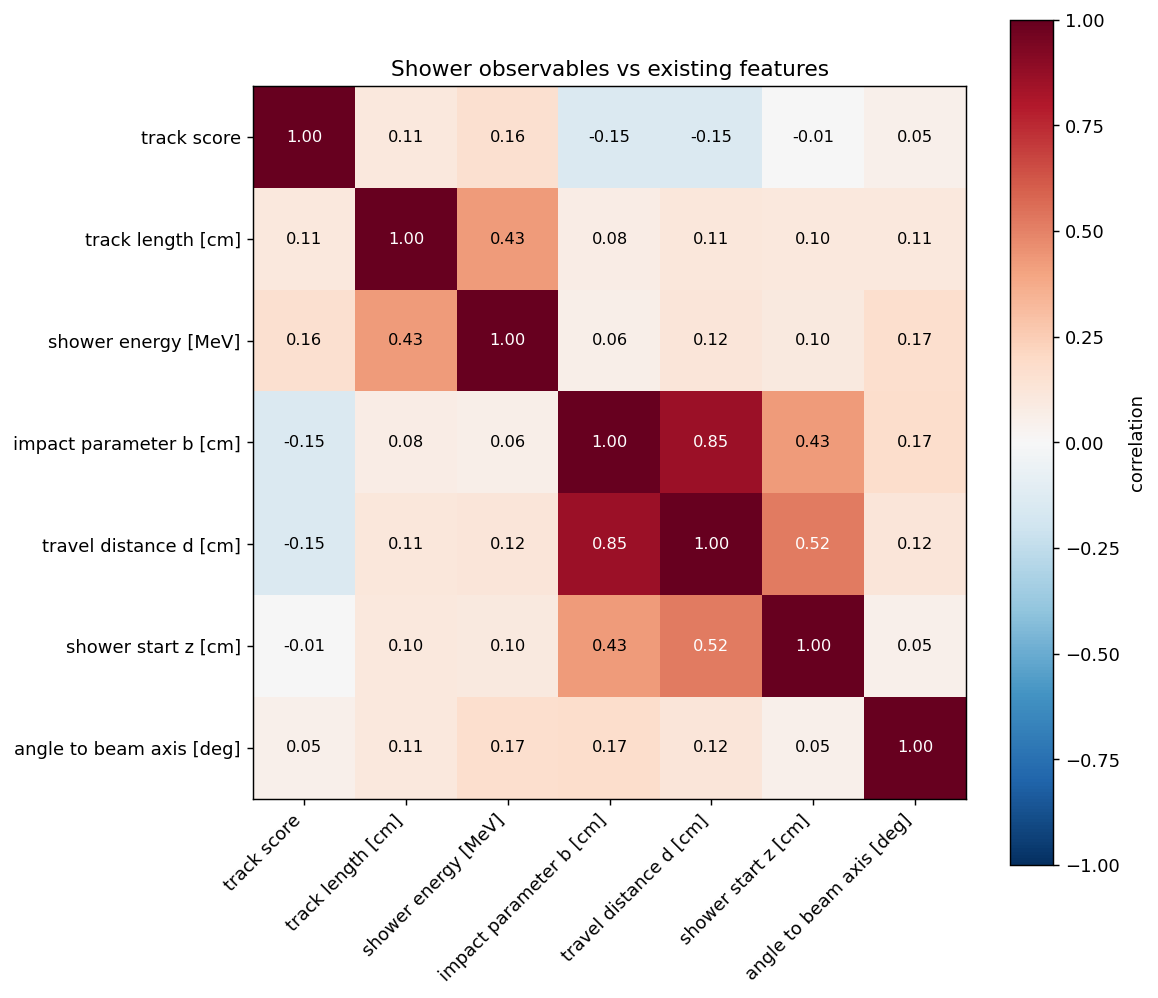

In [21]:
CORR_VARS = ['track score', 'track length [cm]',
             'shower energy [MeV]', 'impact parameter b [cm]',
             'travel distance d [cm]', 'shower start z [cm]',
             'angle to beam axis [deg]']

M  = np.vstack([all_vars[n] for n in CORR_VARS])
ok = np.all(np.isfinite(M), axis=0)
C  = np.corrcoef(M[:, ok])
print(f"correlation computed on {ok.sum():,} PFOs with all variables finite")

fig, ax = plt.subplots(figsize=(9, 8), dpi=130)
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_VARS)))
ax.set_xticklabels(CORR_VARS, rotation=45, ha='right')
ax.set_yticks(range(len(CORR_VARS)))
ax.set_yticklabels(CORR_VARS)
for i in range(len(CORR_VARS)):
    for j in range(len(CORR_VARS)):
        ax.text(j, i, f"{C[i, j]:.2f}", ha='center', va='center',
                fontsize=9, color='white' if abs(C[i, j]) > 0.5 else 'black')
fig.colorbar(im, ax=ax, label='correlation')
ax.set_title('Shower observables vs existing features')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"shower_correlation_matrix_{TARGET}.pdf", bbox_inches='tight')
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score
import numpy as np

sub = is_signal | (species == r'$\gamma$:other')
print(f"{'variable':<30}{'vs all bkg':>12}{'vs γ:other':>12}")
print("-" * 54)
for name in ['impact parameter b [cm]', 'travel distance d [cm]',
             'angle to beam axis [deg]', 'shower energy [MeV]']:
    v = data[name]
    ok_all = np.isfinite(v)
    ok_sub = np.isfinite(v) & sub
    print(f"{name:<30}{roc_auc_score(is_signal[ok_all], v[ok_all]):>12.3f}"
          f"{roc_auc_score(is_signal[ok_sub], v[ok_sub]):>12.3f}")

variable                        vs all bkg  vs γ:other
------------------------------------------------------
impact parameter b [cm]              0.619       0.346
travel distance d [cm]               0.677       0.372
angle to beam axis [deg]             0.364       0.415
shower energy [MeV]                  0.480       0.594


In [23]:
tr = species == r'$\pi^{\pm}$'
for k in ['b', 'd', 'shower_energy']:
    v = np.array([float(t[k]) for t in tracks])
    print(f"{k:<15} tracks: {np.isnan(v[tr]).sum():,} NaN, median {np.nanmedian(v[tr]):.1f}")

b               tracks: 0 NaN, median 1.6
d               tracks: 0 NaN, median 2.9
shower_energy   tracks: 0 NaN, median 155.4


## Against the classifier score

If high-scoring PFOs already have signal-like `b` and `d`, the information is
reaching the model indirectly through correlated inputs. If not, these
variables are genuinely new.

using: hybrid all8 -- photon target


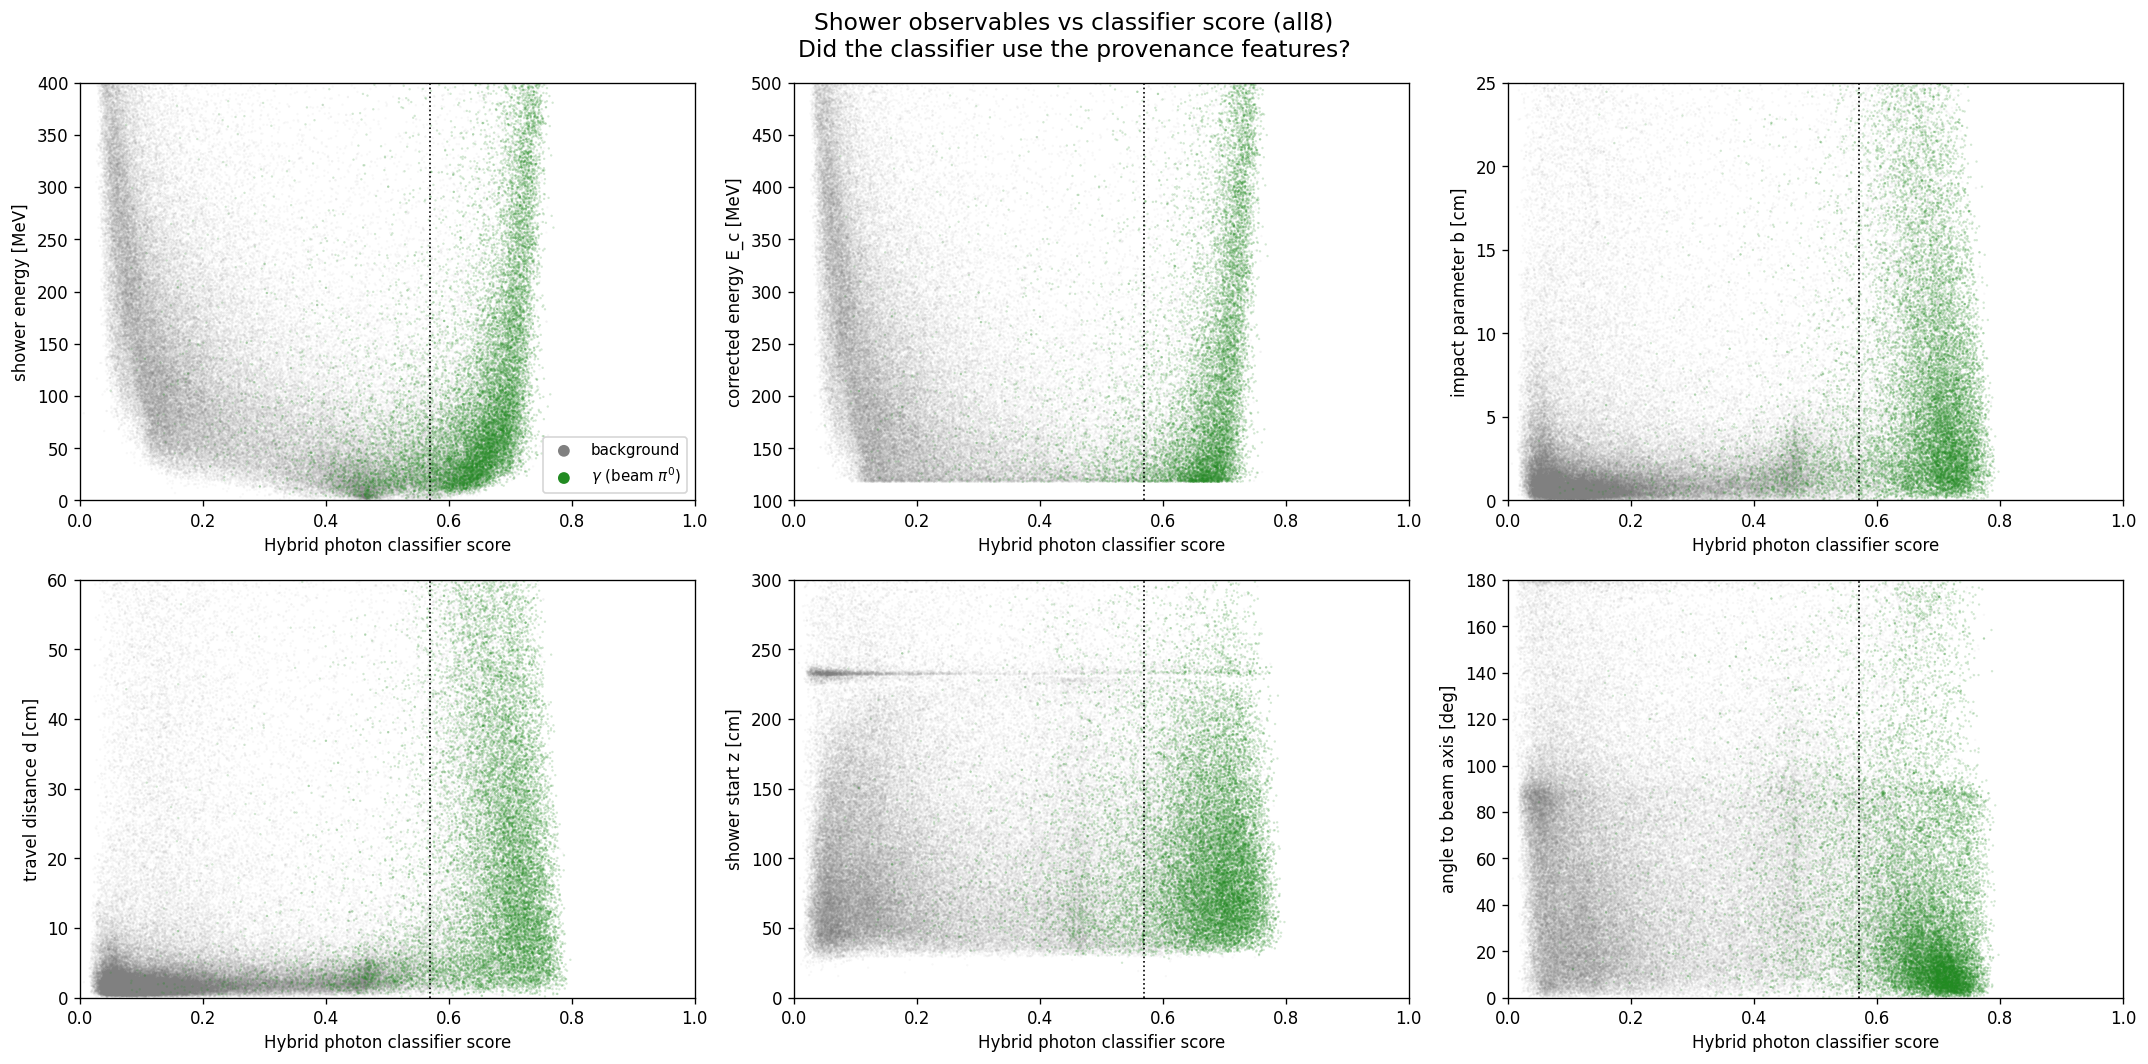

In [24]:
with open(MODEL_PATH, "rb") as f:
    d = pickle.load(f)
probs, thr = np.asarray(d["probs"]), d["threshold"]
assert len(probs) == len(tracks), "predictions misaligned with test PFOs"
print(f"using: {d['model_name']}")

names = list(RANGES)
ncol  = 3
nrow  = int(np.ceil(len(names) / ncol))

fig, ax = plt.subplots(nrow, ncol, figsize=(18, 4.5*nrow), dpi=120)
ax = ax.ravel()
for j, n in enumerate(names):
    v  = data[n]
    ok = np.isfinite(v)
    ax[j].scatter(probs[ok & ~is_signal], v[ok & ~is_signal], s=2, alpha=0.06,
                  color='grey', edgecolors='none', rasterized=True,
                  label='background')
    ax[j].scatter(probs[ok & is_signal], v[ok & is_signal], s=2, alpha=0.20,
                  color=cfg['signal_colour'], edgecolors='none',
                  rasterized=True, label=cfg['signal_name'])
    ax[j].axvline(thr, color='k', ls=':', lw=1)
    ax[j].set_ylim(RANGES[n]); ax[j].set_xlim(0, 1)
    ax[j].set_xlabel(f'Hybrid {TARGET} classifier score')
    ax[j].set_ylabel(n)

for j in range(len(names), len(ax)):
    ax[j].axis('off')
lg = ax[0].legend(fontsize=9, markerscale=5)
for lh in getattr(lg, 'legend_handles', getattr(lg, 'legendHandles', [])):
    lh.set_alpha(1)

fig.suptitle(f"Shower observables vs classifier score ({MODEL_SET})\n{SCORE_TITLE}",fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"shower_observables_vs_score_{MODEL_SET}_{TARGET}.pdf",bbox_inches='tight')
plt.show()

## investigate region between 0.4 and 0.6

In [ ]:
# Region Shyam flagged on 13 Aug: a concentrated cluster of BACKGROUND sitting
# at score 0.4-0.6 with small b, d and angle to beam -- i.e. background with
# signal-like provenance geometry. Two very different explanations are
# possible and this cell distinguishes them:
#   (a) real background photons that happen to point back at the vertex --
#       a genuine physical overlap, not fixable with more features
#   (b) tracks (protons, muons) that also sit near b=d=0 because they
#       originate at the vertex -- a classifier problem, potentially fixable
ROI = ((probs >= 0.40) & (probs <= 0.60) &
       (data['impact parameter b [cm]'] < 5) &
       (data['travel distance d [cm]'] < 10) &
       (data['angle to beam axis [deg]'] < 30) &
       ~is_signal)

print(f"{int(ROI.sum()):,} background PFOs in the region of interest\n")

print(f"{'species':<16}{'count':>8}{'% of ROI':>10}")
print("-" * 34)
for sp, n in Counter(species[ROI]).most_common():
    print(f"{sp:<16}{n:>8,}{100*n/ROI.sum():>9.1f}%")
x
# Track score is the key diagnostic: near 0 means these look like showers
# (explanation a is more likely), near 1 means they look like tracks that
# the model has mis-scored (explanation b).
ts = np.array([float(t['track_score']) for t in tracks])
print(f"\ntrack score in ROI: median {np.median(ts[ROI]):.2f}, "
      f"  {100*np.mean(ts[ROI] > 0.5):.0f}% have track_score > 0.5")

2,778 background PFOs in the region of interest

species            count  % of ROI
----------------------------------
$\pi^{\pm}$        1,050     37.8%
$p$                  711     25.6%
$\pi^{\pm}$:2nd      402     14.5%
$\gamma$:other       250      9.0%
$e^{+}$              193      6.9%
$\mu^{\pm}$          137      4.9%
other                 35      1.3%

track score in ROI: median 0.38,   31% have track_score > 0.5
